<a href="https://colab.research.google.com/github/NaraDaibes/Predictions-Of-Product-Sales/blob/Predictions-Of-Product-Sales/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading Data

In [2]:
from google.colab import files
uploaded = files.upload()


Saving sales_predictions_2023.csv to sales_predictions_2023.csv


In [3]:
import  pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
file='sales_predictions_2023.csv'
df=pd.read_csv(file)
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


# Data Cleaning

In [5]:
# data cleaning duplicate
df.duplicated().sum()


np.int64(0)

In [6]:
# drop duplicates
df.drop_duplicates(inplace=True)

In [7]:
# identify missing values
df.isna().sum()


,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [8]:
# address missing values using placeholder value
df['Item_Weight'].fillna('missing', inplace=True)
df['Outlet_Size'].fillna('missing', inplace=True)



/tmp/ipython-input-1957357238.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna('missing', inplace=True)
/tmp/ipython-input-1957357238.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'missing' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['Item_Weight'].fillna('missing', inplace=True)
/tmp/ipython-input-1957357238.py:3: FutureWarning: A value is trying to be set on a c

In [9]:
#confirm that there is no missing values
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [10]:
# find and fix any inconsistent categories of data # 7
df.nunique()


,0
Item_Identifier,1559
Item_Weight,416
Item_Fat_Content,5
Item_Visibility,7880
Item_Type,16
Item_MRP,5938
Outlet_Identifier,10
Outlet_Establishment_Year,9
Outlet_Size,4
Outlet_Location_Type,3


In [11]:
# check the numerical columns
df.describe()



,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000
mean,0.066132,140.992782,1997.831867,2181.288914
std,0.051598,62.275067,8.371760,1706.499616
min,0.000000,31.290000,1985.000000,33.290000
25%,0.026989,93.826500,1987.000000,834.247400
50%,0.053931,143.012800,1999.000000,1794.331000
75%,0.094585,185.643700,2004.000000,3101.296400
max,0.328391,266.888400,2009.000000,13086.964800


In [12]:
# columns min value
print(df['Item_Visibility'].min())
print(df['Item_MRP'].min())
print(df['Item_Outlet_Sales'].min())
print(df['Outlet_Establishment_Year'].min())

0.0
31.29
33.29
1985


In [14]:
# columns max value
print(df['Item_Visibility'].max())
print(df['Item_MRP'].max())
print(df['Item_Outlet_Sales'].max())
print(df['Outlet_Establishment_Year'].max())

0.328390948
266.8884
13086.9648
2009


In [13]:
# columns mean value
print(df['Item_Visibility'].mean())
print(df['Item_MRP'].mean())
print(df['Item_Outlet_Sales'].mean())
print(df['Outlet_Establishment_Year'].mean())

0.06613202877895108
140.9927819781767
2181.288913575032
1997.8318667135984


In [15]:
# data types
df.dtypes

,0
Item_Identifier,object
Item_Weight,object
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [16]:
# num of rows and columns
df.shape

(8523, 12)

* The histogram aims to visualize the distribution of product prices and identify the most frequent price range, helping to understand common pricing patterns , detect potential outliers, and show if its close to the normal disribution.

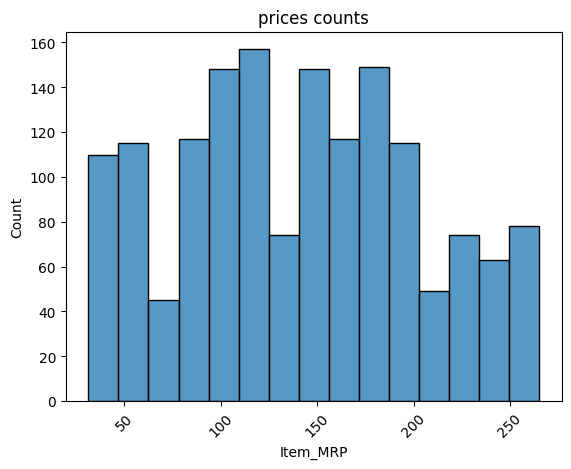

In [17]:
df_unique_products = df.drop_duplicates(subset='Item_Identifier')# to take out the products that has been duplicated
df_unique_products['Item_Identifier'].value_counts()
ax=sns.histplot(data=df_unique_products, x='Item_MRP', bins='auto')
ax.ticklabel_format(style='plain', axis='x')
ax.tick_params(axis='x', rotation=45)
ax.set_title('prices counts')
plt.show()



* The boxplot visualizes the distribution of product prices, showing the median, interquartile range, and potential outliers. It helps to understand the spread of prices and identify unusual values.

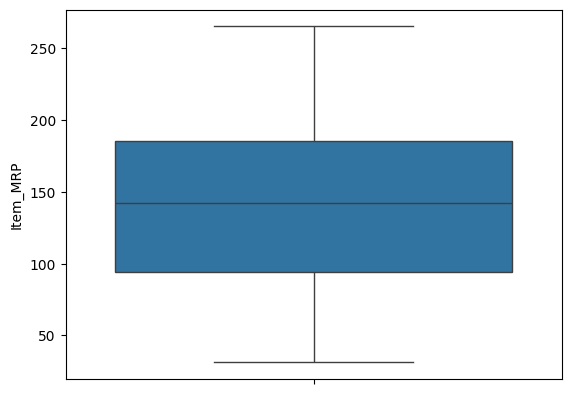

In [18]:
ax=sns.boxplot(data=df_unique_products, y='Item_MRP')

* A barplot was created to compare the average product prices across different outlets.

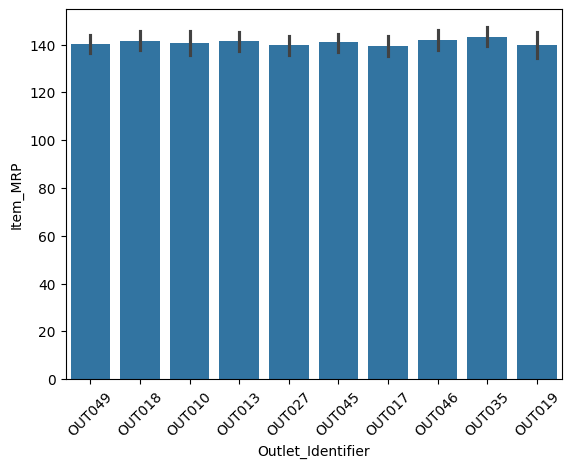

In [19]:
ax=sns.barplot(data=df,x='Outlet_Identifier', y='Item_MRP')
ax.tick_params(axis='x', rotation=45)


* count which type of outlets consumes most items

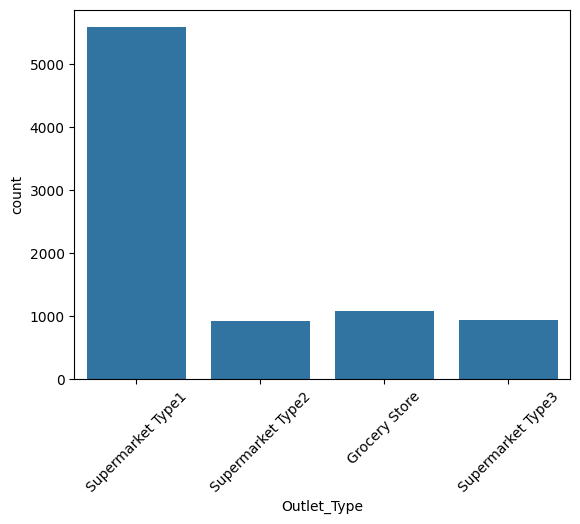

In [20]:
ax=sns.countplot(data=df, x='Outlet_Type')
ax.tick_params(axis='x', rotation=45)

* this count plot can explain why the supermarket type1 in the countplot above counted the highest

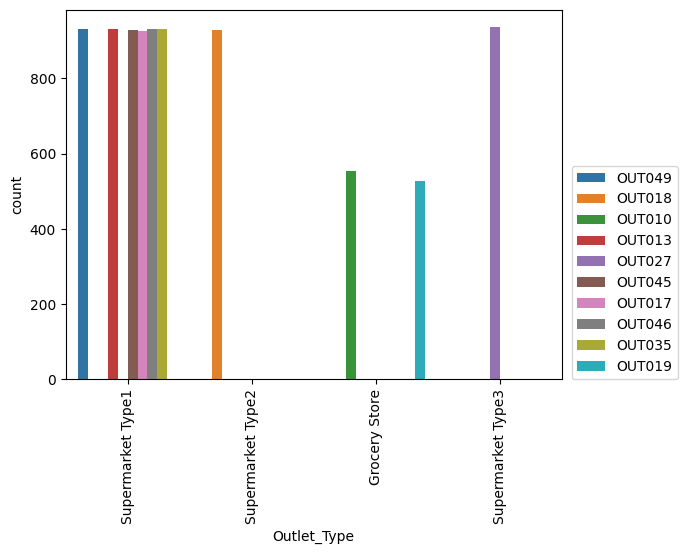

In [21]:
ax=sns.countplot(data=df, x='Outlet_Type', hue='Outlet_Identifier', dodge=True)
ax.tick_params(axis='x', rotation=90)
ax.legend(loc=(1.02,0))

* The number of products in each category based on fat content.



In [22]:

print(df['Item_Fat_Content'].unique())

print(df['Item_Fat_Content'].value_counts()) #count the multiple mentionining of the items


['Low Fat' 'Regular' 'low fat' 'LF' 'reg']
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


/tmp/ipython-input-4122754881.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique_products['Item_Fat_Content'] = df_unique_products['Item_Fat_Content'].replace({


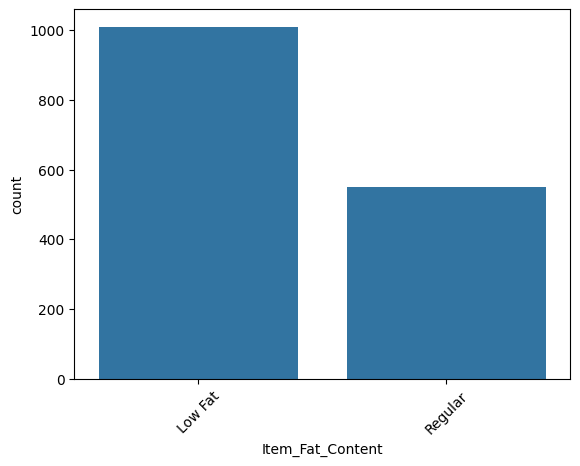

In [23]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'Low Fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})
df_unique_products['Item_Fat_Content'] = df_unique_products['Item_Fat_Content'].replace({
   'low fat': 'Low Fat',
    'Low Fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})

ax=sns.countplot(data=df_unique_products, x='Item_Fat_Content')
ax.tick_params(axis='x', rotation=45)

* calculate the sum of sales for all items in each oulet

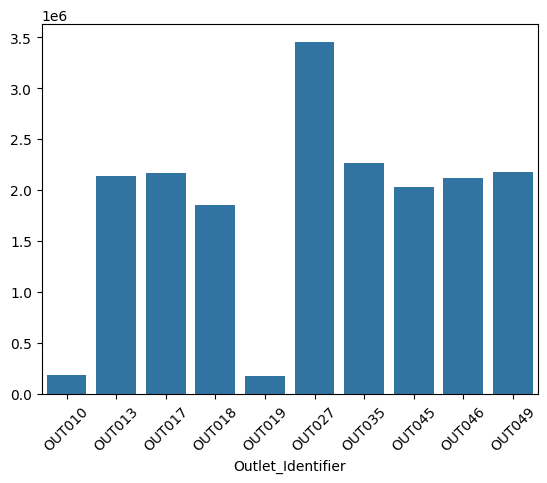

In [25]:
total_sales_per_outlet = df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum()
ax=sns.barplot(x=total_sales_per_outlet.index, y=total_sales_per_outlet.values)
ax.tick_params(axis='x', rotation=45 )

# heatmap

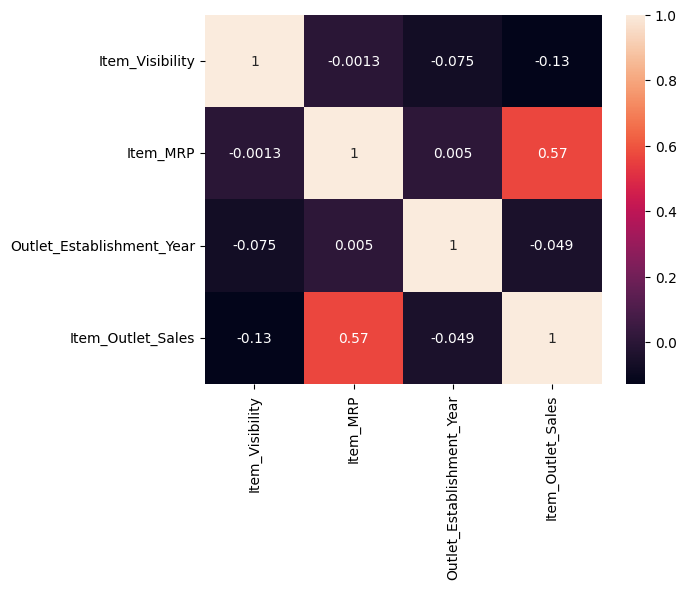

In [27]:
corr=df.corr(numeric_only=True)
ax=sns.heatmap(corr, annot=True)

# Predections of Product Sales
- **Author:** Nara Duaibes
## Project overview ##
## Load and Inspect data ##
In[]:
## Clean Data ##
In[]:
## Exploratory Data Analysis ##
In[]:
## Feature Inspection ##
In[]: